# Sampling from the posterior distribution with `Cobaya`

We also provide a wrapper for `Cobaya`. You can use it by mentioning it in the `theory` block.

In [9]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.usetex'] = False  # Set to True if you have LaTeX installed

In [2]:
info={}
info['theory']={'greapy.cobaya.GREA': None}

info['sampler'] = {'mcmc': {'Rminus1_stop':0.1,'Rminus1_cl_stop':0.5,'max_tries':5_000}}
info['output'] = None

### Likelihood

Next, we specify the likelihood. In this example, we use DESI DR1, but any likelihood installed in Cobaya will do.

In [3]:
info['likelihood']={'bao.desi_2024_bao_all': None}

### Priors

In [4]:
info['params']={
    # Sampled parameters
    'h': {'prior': [0.6, 0.8], 'latex': r'$h$'},
    'omega_cdm': {'prior': [0.1, 0.5], 'latex': r'$\omega_{\rm cdm}$'},
    'omega_b': {'prior': [0.01, 0.1], 'latex': r'$\omega_{\rm b}$'},
    'kappa': {'prior': [2.0, 5.0], 'latex': r'$\sqrt{-k}\eta_0$'},
    # Derived parameters
    'alpha': {'latex': r'$\alpha$'},
    'H0': {'latex': r'$H_0$'},
    'Omega_m': {'latex': r'$\Omega_m$'},
    'rdrag': {'latex': r'$r_{\rm d}$'},
    # Fixed parameters
    'Neff': 3.044
    }

### Sampling

In [5]:
from cobaya.run import run
updated_info, sampler = run(info)

[bao.desi_2024_bao_all] Initialized.
[mcmc] Getting initial point... (this may take a few seconds)
[prior] Reference values or pdfs for some parameters were not provided. Sampling from the prior instead for those parameters.
[mcmc] Initial point: h:0.7292459, omega_cdm:0.4326883, omega_b:0.02035322, kappa:4.601771
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {bao.desi_2024_bao_all: 1820.0, greapy.cobaya.GREA: 107.0}
[prior] *WARNING* Reference pdf not defined or improper for some parameters. Using prior's sigma instead for them.
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2025-07-20 15:02:35 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.015
[mcmc]  - Convergence of means: R-1 = 2.743426 after 128 accepted steps
[mcmc]  - Updat

[root] *WARNING* outlier fraction 0.06101190476190476 


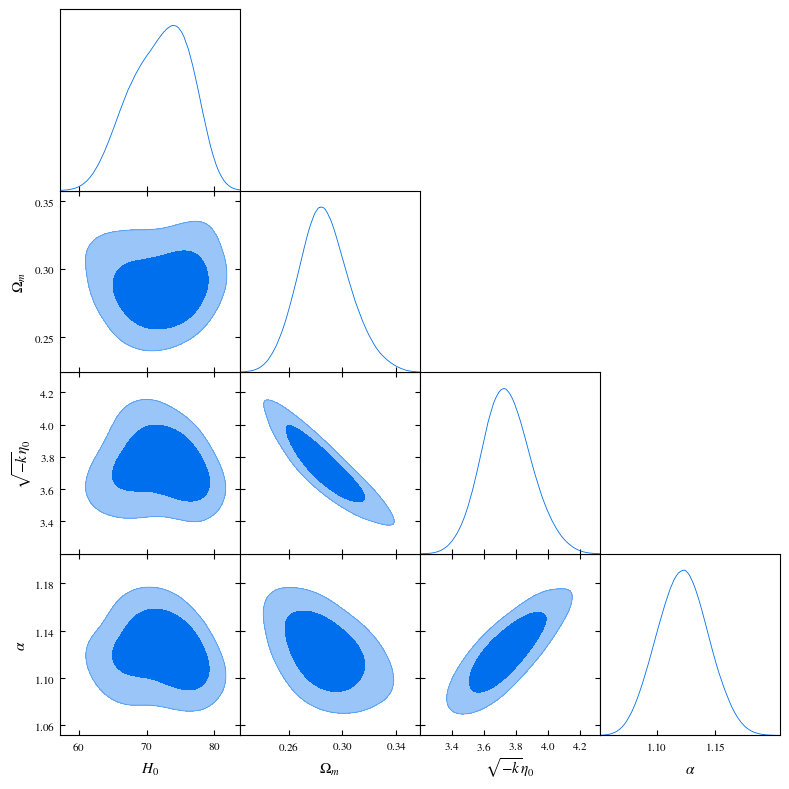

In [ ]:
# Export the results to GetDist
dr1_samples= sampler.products(to_getdist=True,skip_samples=0.3)["sample"]

import getdist.plots as gdplt
%matplotlib notebook

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(dr1_samples, ["H0","Omega_m", "kappa","alpha"], filled=True)

### Updated constraints with DESI DR2

Repeating the analysis with DESI DR2 instead is as simple as changing the likelihood

In [11]:
dr2_info=info.copy() # Copy run settings from DR1
dr2_info['likelihood']={'bao.desi_dr2': None} # Update likelihood to DESI DR2
updated_dr2_info, dr2_sampler = run(dr2_info) # Start the sampling

[bao.desi_dr2] Initialized.


[mcmc] Getting initial point... (this may take a few seconds)
[prior] Reference values or pdfs for some parameters were not provided. Sampling from the prior instead for those parameters.
[mcmc] Initial point: h:0.6426293, omega_cdm:0.4554333, omega_b:0.0290452, kappa:2.132855
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {bao.desi_dr2: 2050.0, greapy.cobaya.GREA: 82.7}
[prior] *WARNING* Reference pdf not defined or improper for some parameters. Using prior's sigma instead for them.
[mcmc] Covariance matrix not present. We will start learning the covariance of the proposal earlier: R-1 = 30 (would be 2 if all params loaded).
[mcmc] Sampling!
[mcmc] Progress @ 2025-07-20 15:07:06 : 1 steps taken, and 0 accepted.
[mcmc] Learn + convergence test @ 160 samples accepted.
[mcmc]  - Acceptance rate: 0.008
[mcmc]  - Convergence of means: R-1 = 1.137087 after 128 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Lea

[root] *WARNING* outlier fraction 0.022058823529411766 


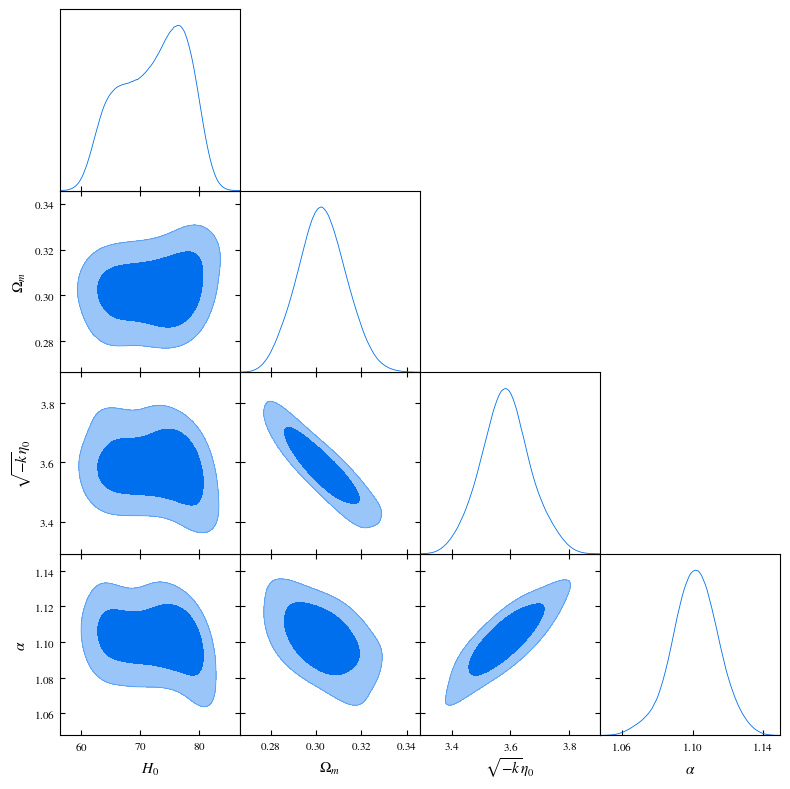

In [ ]:
%matplotlib notebook
dr2_samples= dr2_sampler.products(to_getdist=True,skip_samples=0.3)["sample"]

gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(dr2_samples, ["H0","Omega_m", "kappa","alpha"], filled=True)

### DR1 vs DR2

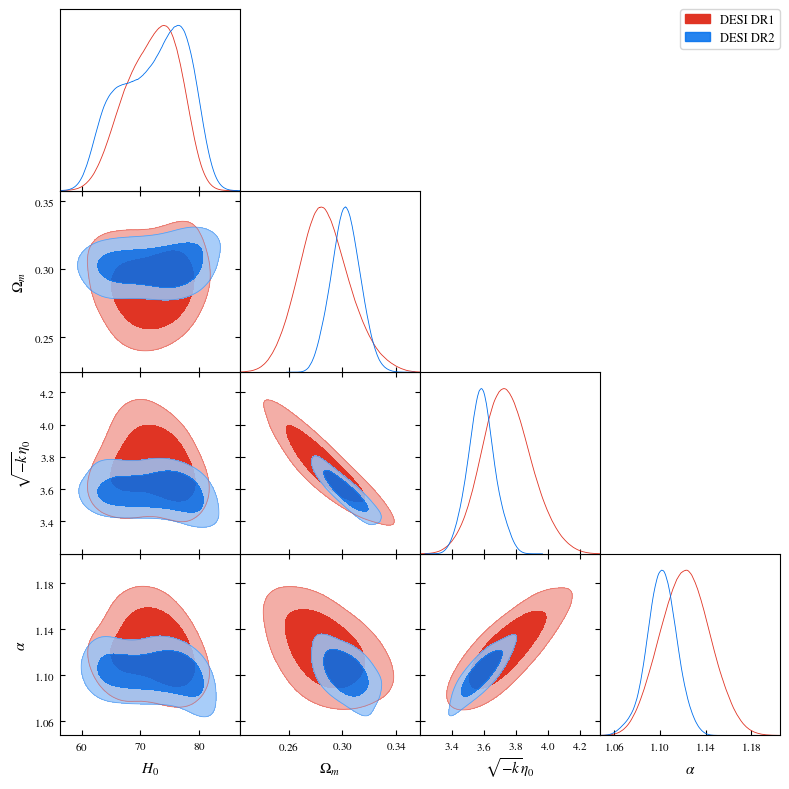

In [ ]:
%matplotlib notebook
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot([dr1_samples,dr2_samples], ["H0","Omega_m", "kappa","alpha"], filled=True, legend_labels=["DESI DR1","DESI DR2"], legend_loc='upper right'  )